# TFSF Sources in FDTDX

This notebook explains **what a TFSF source is, why FDTD simulations need one, and how to build one with `fdtdx.TFSFPlaneSourceRegion`.**

## 1. What is a TFSF source, and why do we need one?

Say you want to simulate light hitting a nanoparticle and measure what it *scatters* — a Mie-scattering
cross-section, a radar cross-section, the diffraction efficiency of a grating. You need two things that
are in tension with each other:

- A **clean, textbook incident wave** hitting the object — no reflections, no discretization artifacts,
  ideally exactly the plane wave you'd write down analytically.
- A way to isolate **only the scattered field** on the way out, so you can absorb it in PML (or Fourier-
  transform it into a far field) without the enormous, un-scattered incident wave swamping the signal.

A simple plane-wave source (`fdtdx.UniformPlaneSource`) launches a wave from one plane and lets it
propagate forever in one direction. That's a fine *illuminator*, but incident and scattered light are
mixed together everywhere downstream of the source plane — there is no clean place to say "this part is
purely scattered". It also usually needs periodic boundaries on the sides to look like an infinite sheet.

**Total-Field/Scattered-Field (TFSF)** solves this with a classic trick from the FDTD literature. Draw a
closed box around the region of interest. On every face of that box, inject a correction term equal to
the exact incident field, with a sign chosen so that:

- **Inside the box:** total field = incident + scattered — whatever's physically there.
- **Outside the box:** the incident field is exactly cancelled at every point of the boundary the instant
  it would cross it, so **only the scattered field remains**. If the box is empty, the outside is
  (numerically) zero.

That gives you the best of both: a perfect incident wave inside, and a scattered-field-only region outside
that terminates cleanly in ordinary PML — no periodic boundary trick required — and that is exactly the
signal you want for far-field or cross-section calculations.


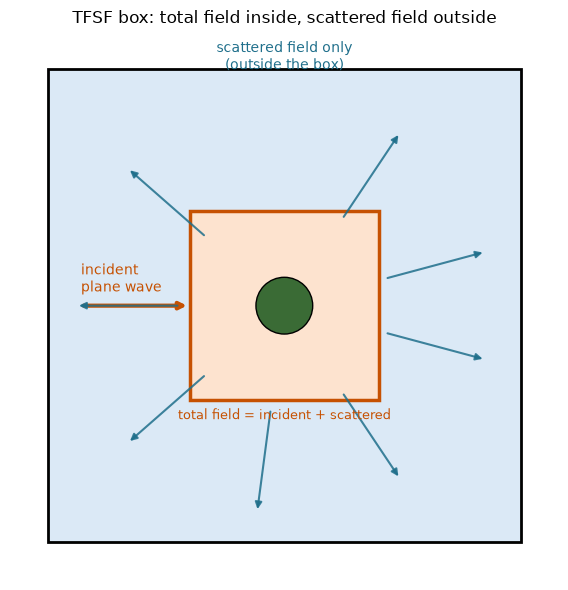

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6))

# Outer simulation domain, terminated in ordinary PML
outer = patches.Rectangle((-5, -5), 10, 10, linewidth=2, edgecolor="black",
                           facecolor="#dbe9f6")
ax.add_patch(outer)

# TFSF box: total field lives inside this surface
box = patches.Rectangle((-2, -2), 4, 4, linewidth=2.5, edgecolor="#c65102",
                         facecolor="#fde3cf")
ax.add_patch(box)

# a scatterer sitting inside the box
scatterer = patches.Circle((0, 0), 0.6, facecolor="#3a6b35", edgecolor="black")
ax.add_patch(scatterer)

# incident wave entering through the box's left face
ax.annotate("", xy=(-2, 0), xytext=(-4.3, 0),
            arrowprops=dict(arrowstyle="-|>", color="#c65102", lw=3))
ax.text(-4.3, 0.3, "incident\nplane wave", color="#c65102", fontsize=10, ha="left")

# scattered field radiating outward through the box boundary in every direction
for ang in np.linspace(15, 345, 9):
    if 80 < ang < 100:
        continue
    rad = np.deg2rad(ang)
    x0, y0 = 2.2 * np.cos(rad), 2.2 * np.sin(rad)
    x1, y1 = 4.4 * np.cos(rad), 4.4 * np.sin(rad)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color="#1f6f8b", lw=1.5, alpha=0.85))

ax.text(0, 5.0, "scattered field only\n(outside the box)", color="#1f6f8b",
        fontsize=10, ha="center")
ax.text(0, -2.4, "total field = incident + scattered", color="#c65102",
        fontsize=9, ha="center")

ax.set_xlim(-5.8, 5.8)
ax.set_ylim(-5.8, 5.8)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("TFSF box: total field inside, scattered field outside")
plt.tight_layout()
plt.show()


## 2. TFSF sources in FDTDX

Under the hood, *every* directional plane-type source in fdtdx — `UniformPlaneSource`,
`GaussianPlaneSource`, `ModePlaneSource` — is built on a shared base class (`TFSFPlaneSource`) that already
applies the one-directional TFSF correction on a *single* plane: that's what lets a plane source inject a
wave that only propagates to one side of it, instead of in both directions at once.

What we're using in this tutorial is the class fdtdx exposes for the *full, closed-box* version of the
technique: **[`fdtdx.TFSFPlaneSourceRegion`](https://fdtdx.readthedocs.io/en/latest/api/fdtdx.TFSFPlaneSourceRegion.html)**.
From the docs:

> A uniform plane wave is injected on the bounding faces of a rectangular box so that the **total field
> lives inside the box** and **only the scattered field exists outside**. [...] Every active face evaluates
> *one coherent* plane wave sharing a single spatial phase origin (the box lower corner): the entry faces
> launch the wave and the exit faces terminate it (sign-flipped), keeping the propagation direction of
> `k = E x H` intact.

In other words: unlike a single-plane source, `TFSFPlaneSourceRegion` is a **volume object** — it has an
explicit `propagation_axis`, and by default it injects a correction on *every* face of the box (both caps
on the propagation axis, and both faces of each transverse axis), which is what confines the incident wave
strictly to the box interior.

Let's build one.


## 3. Building the scene: config, volume, boundaries

We start the same way every fdtdx simulation starts: a random key (fdtdx/JAX plumbing — this simulation is
fully deterministic, but the key is still required), a `SimulationConfig`, and a `SimulationVolume` with a
background material.


In [46]:
import time

import jax
import jax.numpy as jnp
from IPython.display import Video

import fdtdx
%matplotlib inline

In [48]:
# Random key for FDTDX
key = jax.random.PRNGKey(seed=42)

object_list = []

# Duration, spatial resolution, numeric dtype and Courant stability factor
config = fdtdx.SimulationConfig(
    time=130e-15,
    grid=fdtdx.UniformGrid(spacing=100e-9),
    dtype=jnp.float32,
    courant_factor=0.99,
)


In [13]:
volume = fdtdx.SimulationVolume(
    partial_real_shape=(12e-6, 12e-6, 12e-6),
    material=fdtdx.Material(  # background material = vacuum/air
        permittivity=1.0,
        permeability=1.0,
    ),
)
object_list.append(volume)


Here is the detail that matters most for this tutorial: because the TFSF box supplies its own
self-consistent plane wave on all six faces, **the simulation boundary does not need to be periodic**. A
plain `UniformPlaneSource` typically needs periodic (or Bloch) boundaries on the transverse sides so that
an infinite plane wave doesn't reflect off finite side walls. A TFSF box doesn't need that trick — we can
terminate every side with ordinary absorbing PML.


In [16]:
constraints = []

# Absorbing PML on all six sides — no periodicity required for a TFSF box.
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(boundary_type="pml", thickness=10)
bound_dict, bc_constraints = fdtdx.boundary_objects_from_config(bound_cfg, volume)
constraints.extend(bc_constraints)
object_list.extend(bound_dict.values())


## 4. The TFSF box source, parameter by parameter

A few of the constructor arguments deserve a closer look

| Parameter | Meaning |
|---|---|
| `propagation_axis` | Which grid axis (`0`=x, `1`=y, `2`=z) the wave travels along. Required — unlike a plane source, a box has no "thin" axis to infer this from. |
| `direction` | `"+"` or `"-"`: which way along `propagation_axis` the wave travels. |
| `wave_character` | A `fdtdx.WaveCharacter` — give it a `wavelength`, `period`, *or* `frequency` (mutually exclusive) plus an optional `phase_shift`. |
| `partial_real_shape` / `partial_real_position` | The physical size/position of the box (meters). You can mix these with `partial_grid_shape` (Yee-grid cells), exactly like any other fdtdx object. |
| `fixed_E_polarization_vector` | A fixed `(x, y, z)` unit-ish vector for the incident E-field polarization (optional — omit it and fdtdx will pick a sensible default). |
| `periodic_axes` | Transverse axes to treat as periodic "wrap-around" instead of injecting a correction on their faces — see [Section 10](#10.-Periodic-TFSF-boxes-(gratings)-&-oblique-incidence). |
| `azimuth_angle`, `elevation_angle` | Tilt the incident wave for oblique-incidence studies. |
| `amplitude`, `static_amplitude_factor` | Scale the injected field. |
| `switch` | An `OnOffSwitch` controlling *when* the source is active (defaults to always on). |
| `temporal_profile` | Defaults to a `SingleFrequencyProfile` — a smoothly ramped-up continuous wave. |

We'll place a 6×6×6 µm box at the center of our 12×12×12 µm volume — that leaves a clear ~2 µm
scattered-field buffer between the box and the PML on every side (PML itself eats another ~1 µm at 10
cells / 100 nm resolution).


In [19]:
tfsf_box = fdtdx.TFSFPlaneSourceRegion(
    partial_real_shape=(6e-6, 6e-6, 6e-6),           # a 6 micron cube ...
    wave_character=fdtdx.WaveCharacter(wavelength=1.55e-6),
    propagation_axis=2,                              # ... wave travels along z ...
    direction="+",                                   # ... from -z towards +z
    fixed_E_polarization_vector=(1, 0, 0),            # Ex-polarized
    name="TFSF_box",
)
object_list.append(tfsf_box)

# Only a position constraint is needed — the size was already fixed above.
constraints.append(tfsf_box.place_at_center(volume))


## 5. A detector to watch the field

To actually *see* the total-field / scattered-field split, we attach an `EnergyDetector` spanning the
whole simulation volume and turn it into a video, exactly as in the
[Uniform Plane Source](https://fdtdx.readthedocs.io/en/latest/notebooks/components/01_uniform_plane_source.html)
tutorial. `as_slices=True` keeps memory usage down by only storing the 2D slice that actually gets plotted.


In [22]:
video_energy_detector = fdtdx.EnergyDetector(
    name="Video",
    as_slices=True,
    switch=fdtdx.OnOffSwitch(interval=3),
    exact_interpolation=True,
    num_video_workers=8,
)
object_list.append(video_energy_detector)
constraints.extend(video_energy_detector.same_position_and_size(volume))


## 6. Resolving placement & inspecting the scene

`fdtdx.place_objects` resolves every constraint we've collected into concrete grid positions. It's good
practice to immediately plot the result with `fdtdx.plot_setup` and check nothing looks wrong before
spending time on a full run.


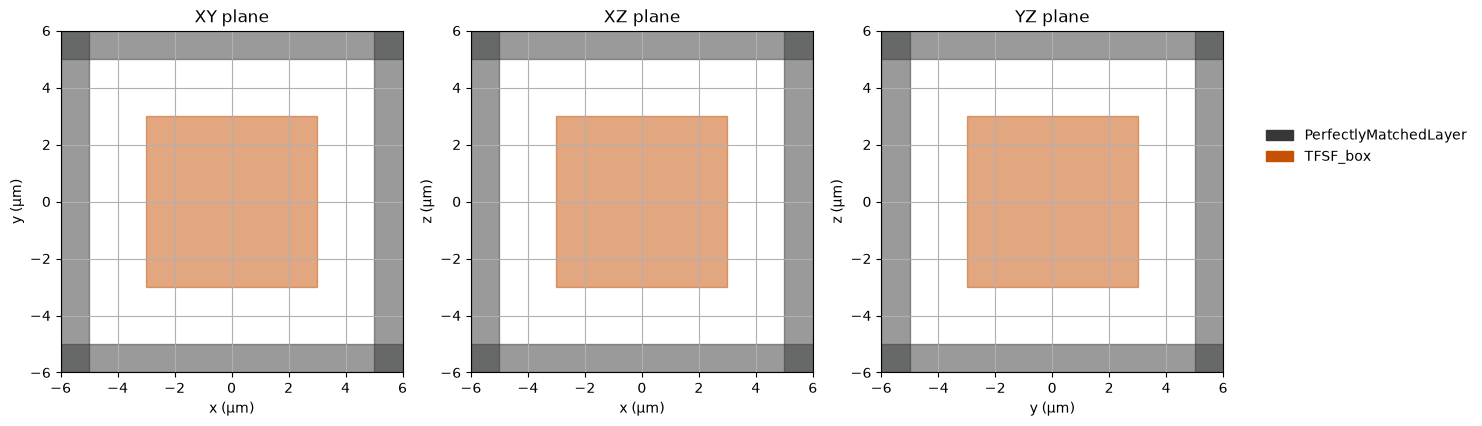

In [25]:
key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list,
    config=config,
    constraints=constraints,
    key=subkey,
)

fig = fdtdx.plot_setup(
    config=config,
    objects=objects,
    exclude_object_list=[video_energy_detector],
)
plt.show()


You should see the orange TFSF box sitting at the center of the volume, well clear of the PML layer at the
edges — with nothing else in the scene yet.


## 7. Test 1 — an empty box (sanity check)

Before adding anything to scatter off, let's run the empty box and confirm the claim from Section 1: with
nothing inside to scatter the wave, the scattered field should be (numerically) zero, so **nothing should
appear outside the box at all** — only the clean plane wave sweeping through the interior.

Running an FDTD step in fdtdx is a two-part process: `apply_params` prepares the (here trivial) parametric
objects and precomputes some values, then `run_fdtd` performs the actual time-stepping loop.


In [29]:
def sim_fn(
    params: fdtdx.ParameterContainer,
    arrays: fdtdx.ArrayContainer,
    key: jax.Array,
):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects, params, key)
    final_state = fdtdx.run_fdtd(
        arrays=arrays,
        objects=new_objects,
        config=config,
        key=key,
    )
    _, arrays = final_state
    return arrays


start_time = time.time()
jitted_sim = jax.jit(sim_fn).lower(params, arrays, key).compile()
print(f"Compilation time: {time.time() - start_time:.1f} s")


Compilation time: 0.6 s


In [31]:
start_time = time.time()
new_arrays_empty = jitted_sim(params, arrays, subkey)
print(f"Simulation runtime: {time.time() - start_time:.1f} s")


FDTD (checkpointed):   0%|                            | 0/682 [00:00<?, ?step/s]

Simulation runtime: 6.3 s


In [33]:
video_path_empty = objects["Video"].draw_plot(new_arrays_empty.detector_states["Video"])
Video(list(video_path_empty.values())[0], embed=True, width=720)


**What to look for:** inside the orange box outline you should see a clean plane wavefront sweep through
in the +z direction. The moment that wavefront reaches the box boundary it should vanish — outside the box,
energy should stay at (numerical-noise) zero for the entire run. That's the TFSF correction doing exactly
what it promises: with nothing to scatter off, the scattered field really is zero, so there's nothing left
to see outside.


## 8. Test 2 — add a scatterer

Now let's put something inside the box for the incident wave to scatter off: a small dielectric cube,
centered on the TFSF box itself.


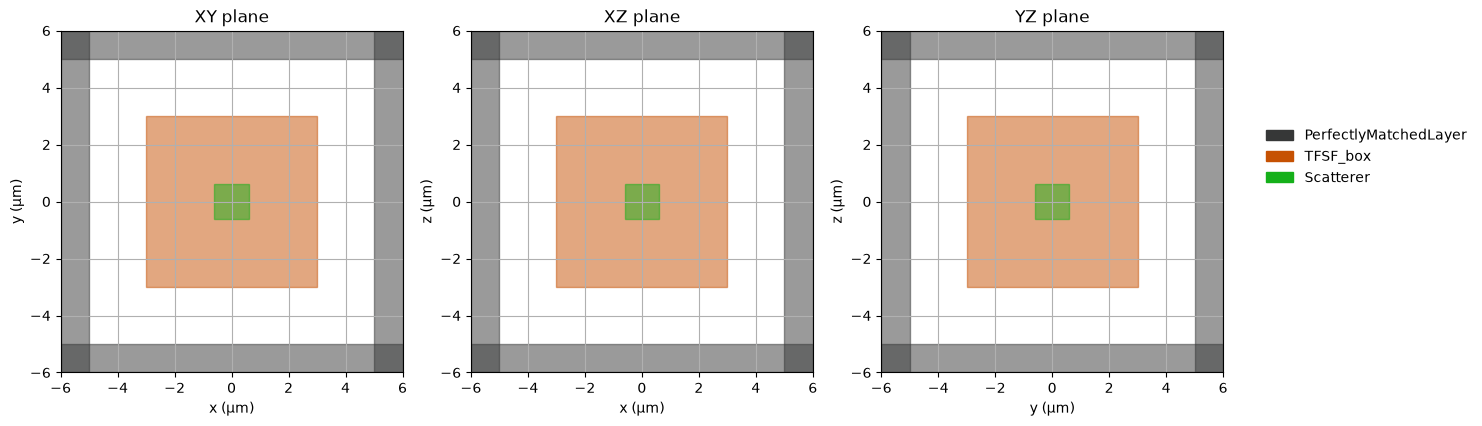

In [36]:
scatterer = fdtdx.UniformMaterialObject(
    partial_real_shape=(1.2e-6, 1.2e-6, 1.2e-6),
    material=fdtdx.Material(permittivity=fdtdx.constants.relative_permittivity_silicon),
    name="Scatterer",
    color=fdtdx.colors.GREEN,
)

object_list_2 = object_list + [scatterer]
constraints_2 = constraints + [scatterer.place_at_center(tfsf_box)]

key, subkey = jax.random.split(key)
objects2, arrays2, params2, config2, _ = fdtdx.place_objects(
    object_list=object_list_2,
    config=config,
    constraints=constraints_2,
    key=subkey,
)

fig = fdtdx.plot_setup(
    config=config2,
    objects=objects2,
    exclude_object_list=[video_energy_detector],
)
plt.show()


In [38]:
def sim_fn_scatter(
    params: fdtdx.ParameterContainer,
    arrays: fdtdx.ArrayContainer,
    key: jax.Array,
):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects2, params, key)
    final_state = fdtdx.run_fdtd(
        arrays=arrays,
        objects=new_objects,
        config=config2,
        key=key,
    )
    _, arrays = final_state
    return arrays


jitted_sim_scatter = jax.jit(sim_fn_scatter).lower(params2, arrays2, key).compile()
new_arrays_scatter = jitted_sim_scatter(params2, arrays2, subkey)


FDTD (checkpointed):   0%|                            | 0/682 [00:00<?, ?step/s]

In [40]:
video_path_scatter = objects2["Video"].draw_plot(new_arrays_scatter.detector_states["Video"])
Video(list(video_path_scatter.values())[0], embed=True, width=720)


**Compare this to Test 1:** the plane wave still sweeps cleanly through the box interior — that part hasn't
changed. But now, once the wavefront reaches the cube, part of it scatters, and *that* scattered energy
does cross the box boundary, radiating outward in every direction toward the PML — not just forward, the
way it would with a plain plane-wave source. That outward-radiating pattern outside the box, and only that
pattern, is the physical scattered field: exactly the signal you'd feed into a far-field projection or a
scattering-cross-section calculation.
